# Performing Principal Component Analysis

## Step 1: Get some data

To start, generate some data for PCA!

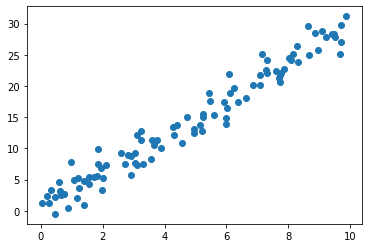

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)

x1 = np.random.uniform(low=0, high=10, size=100)
x2 = [(xi*3)+np.random.normal(scale=2) for xi in x1]
plt.scatter(x1, x2);

## Step 2: Subtract the mean

Next, you have to subtract the mean from each dimension of the data.

In [ ]:
import pandas as pd

data = pd.DataFrame([x1,x2]).transpose()
data.columns = ['x1', 'x2']
data.head()

,x1,x2
0,3.745401,11.410298
1,9.507143,27.923414
2,7.319939,22.143340
3,5.986585,13.984617
4,1.560186,4.241215


In [ ]:
data.mean()

x1     4.701807
x2    14.103262
dtype: float64

In [ ]:
mean_centered = data - data.mean()
mean_centered.head()

,x1,x2
0,-0.956406,-2.692964
1,4.805336,13.820153
2,2.618132,8.040078
3,1.284777,-0.118645
4,-3.141621,-9.862046


## Step 3: Calculate the covariance matrix

Now that you have normalized your data, you can calculate the covariance matrix.

In [ ]:
cov = np.cov([mean_centered['x1'], mean_centered['x2']])
cov

array([[ 8.84999497, 25.73618675],
       [25.73618675, 78.10092586]])

## Step 4: Calculate the eigenvectors and eigenvalues of the covariance matrix

It's time to compute the associated eigenvectors. These will form the new axes when it's time to reproject the dataset on the new basis.

In [ ]:
eigen_value, eigen_vector = np.linalg.eig(cov)
eigen_vector

array([[-0.94936397, -0.31417837],
       [ 0.31417837, -0.94936397]])

In [ ]:
eigen_value

array([ 0.33297363, 86.61794719])

## Step 5: Choosing components and forming a feature vector

If you look at the eigenvectors and eigenvalues above, you can see that the eigenvalues have very different values. In fact, it turns out that **the eigenvector with the highest eigenvalue is the principal component of the dataset.**

In general, once eigenvectors are found from the covariance matrix, the next step is to order them by eigenvalue in descending order. This gives us the components in order of significance. Typically, PCA will be used to reduce the dimensionality of the dataset and as such, some of these eigenvectors will be subsequently discarded. In general, the smaller the eigenvalue relative to others, the less information encoded within said feature.

Finally, you need to form a __feature vector__, which is just a fancy name for a matrix of vectors. This is constructed by taking the eigenvectors that you want to keep from the list of eigenvectors, and forming a matrix with these eigenvectors in the columns as shown below:

In [ ]:
# Get the index values of the sorted eigenvalues
e_indices = np.argsort(eigen_value)[::-1] 

# Sort
eigenvectors_sorted = eigen_vector[:, e_indices]
eigenvectors_sorted

array([[-0.31417837, -0.94936397],
       [-0.94936397,  0.31417837]])

## Step 5: Deriving the new dataset

This the final step in PCA, and is also the easiest. Once you have chosen the components (eigenvectors) that you wish to keep in our data and formed a feature vector, you simply take the transpose of the vector and multiply it on the left of the original dataset, transposed.

In [ ]:
transformed = eigenvectors_sorted.dot(mean_centered.T).T
transformed[:5]

array([[  2.85708504,   0.06190663],
       [-14.63008778,  -0.2200194 ],
       [ -8.45552104,   0.04045849],
       [ -0.29101209,  -1.25699704],
       [ 10.34970068,  -0.11589976]])

---

In [ ]:
import numpy as np
X = np.array([[0.1, 0.3, 0.4, 0.8, 0.9], 
              [3.2, 2.4, 2.4, 0.1, 5.5], 
              [10., 8.2, 4.3, 2.6, 0.9]])

print(X)

[[ 0.1  0.3  0.4  0.8  0.9]
 [ 3.2  2.4  2.4  0.1  5.5]
 [10.   8.2  4.3  2.6  0.9]]


In [ ]:
print(np.cov(X))

[[ 0.115   0.0575 -1.2325]
 [ 0.0575  3.757  -0.8775]
 [-1.2325 -0.8775 14.525 ]]


The diagonal elements, $C_{ii}$ are the variances in the variables $x_i$ assuming $N−1$ degrees of freedom:

In [ ]:
print(np.var(X, axis=1, ddof=1))

[ 0.115  3.757 14.525]


## Eigendecomposition

The eigendecomposition is one form of matrix decomposition. Decomposing a matrix means that you want to find a product of matrices that is equal to the initial matrix. In the case of the eigendecomposition, you decompose the initial matrix into the product of its __eigenvectors__ and __eigenvalues__.
 
A vector $v$ is an __eigenvector__ of a __square__ matrix $A$ if it satisfies the following equation:

$$Av = \lambda v$$.


Here, __lambda__ ($\lambda$) represents the __eigenvalue__ scalar.

> A matrix can have one eigenvector and eigenvalue for each dimension of the parent matrix. 

Also, remember that not all square matrices can be decomposed into eigenvectors and eigenvalues, and some can only be decomposed in a way that requires complex numbers.

__The parent matrix can be shown to be a product of the eigenvectors and eigenvalues.__

$$A = Q . diag(V) . Q^{-1}$$

$Q$ is a matrix comprised of the eigenvectors, $diag(V)$ is a diagonal matrix comprised of the __eigenvalues__ along the diagonal (and zeros everywhere else), and $Q^{-1}$ is the inverse of the matrix comprised of the eigenvectors.

A decomposition operation breaks down a matrix into constituent parts to make certain operations on the matrix easier to perform. Eigendecomposition is used as an element to simplify the calculation of other, more complex matrix operations.

## Eigenvectors and Eigenvalues

__Eigenvectors__ are unit vectors, with length or magnitude equal to 1.0. They are often referred to as right vectors, which simply means a column vector (as opposed to a row vector or a left vector). Imagine a transformation matrix that, when multiplied on the left, reflected vectors in the line $y=x$. You can see that if there were a vector that lay on the line $y=x$, it’s reflection is itself. This vector (and all multiples of it), would be an eigenvector of that transformation matrix.


<img src='assets/pca_covariance_matrix_eigendecomp/new_eig1.png' width='400'>

__Eigenvalues__ are coefficients applied to eigenvectors that give the vectors their length or magnitude. For example, a negative eigenvalue may reverse the direction of the eigenvector as part of scaling it. Eigenvalues are closely related to eigenvectors.

A matrix that has only positive eigenvalues is referred to as a __positive definite matrix__, whereas if the eigenvalues are all negative, it is referred to as a __negative definite matrix__.

Decomposing a matrix in terms of its eigenvalues and its eigenvectors gives valuable insights into the properties of the matrix. Certain matrix calculations, like computing the power of the matrix, become much easier when we use the eigendecomposition of the matrix. The eigendecomposition can be calculated in NumPy using the `eig()` function.

The example below first defines a 3×3 square matrix. The eigendecomposition is calculated on the matrix returning the eigenvalues and eigenvectors using the `eig()` function.

In [ ]:
# Eigendecomposition
from numpy import array
from numpy.linalg import eig
# Define matrix
A = array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(A)
print('-----------------')
# Calculate eigendecomposition
values, vectors = eig(A)
print(values)
print('-----------------')
print(vectors)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
-----------------
[ 1.61168440e+01 -1.11684397e+00 -9.75918483e-16]
-----------------
[[-0.23197069 -0.78583024  0.40824829]
 [-0.52532209 -0.08675134 -0.81649658]
 [-0.8186735   0.61232756  0.40824829]]


## Testing an Eigenvector

Above, the eigenvectors are returned as a matrix with the same dimensions as the parent matrix (3x3), where each column is an eigenvector, e.g. the first eigenvector is vectors[:,0]. Eigenvalues are returned as a list, where value indices in the returned array are paired with eigenvectors by column index, e.g. the first eigenvalue at values[0] is paired with the first eigenvector at vectors[: 0].

You can also test whether the first vector and value are in fact an eigenvalue and eigenvector for the matrix.

In [ ]:
# Confirm first eigenvector
B = A.dot(vectors[:, 0])
print(B)
print('-----------------')
C = vectors[:, 0] * values[0]
print(C)

[ -3.73863537  -8.46653421 -13.19443305]
-----------------
[ -3.73863537  -8.46653421 -13.19443305]


## Reconstruct Original Matrix

You can also reverse the process and reconstruct the original matrix given only the eigenvectors and eigenvalues.

First, the list of eigenvectors must be converted into a matrix, where each vector becomes a row. The eigenvalues need to be arranged into a diagonal matrix. The NumPy `diag()` function can be used for this. Next, you need to calculate the inverse of the eigenvector matrix, which we can be achieved with the `inv()` function. Finally, these elements need to be multiplied together with the `.dot()` method.

In [ ]:
from numpy.linalg import inv
# Create matrix from eigenvectors
Q = vectors

# Create inverse of eigenvectors matrix
R = inv(Q)

# Create diagonal matrix from eigenvalues
L = np.diag(values)

# Reconstruct the original matrix
B = Q.dot(L).dot(R)
print(B)

[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


## Summary 

In this lesson, you looked at calculating the covariance matrix for a given matrix. You also looked at eigendecomposition and its implementation in Python. You can now go ahead and use these skills to apply principal component analysis for a multidimensional dataset using these skills.

---

## Import the data

- Import the data stored in the file `'data/pca_numpy_lab/foodusa.csv'` (set `index_col=0`)
- Print the first five rows of the DataFrame

In [ ]:
import pandas as pd
data = None



## Normalize the data

Next, normalize your data by subtracting the mean from each of the columns.

In [ ]:
data = None
data.head()

## Calculate the covariance matrix

The next step is to calculate the covariance matrix for your normalized data.

In [ ]:
cov_mat = None
cov_mat

## Calculate the eigenvectors

Next, calculate the eigenvectors and eigenvalues for your covariance matrix.

In [ ]:
import numpy as np
eig_values, eig_vectors = None

## Sort the eigenvectors 

Great! Now that you have the eigenvectors and their associated eigenvalues, sort the eigenvectors based on their eigenvalues to determine primary components!

In [ ]:
# Get the index values of the sorted eigenvalues
e_indices = None

# Sort 
eigenvectors_sorted = None
eigenvectors_sorted

## Reprojecting the data

Finally, reproject the dataset using your eigenvectors. Reproject this dataset down to 2 dimensions.